# Intro

Cell type annotation is a topic of much discussion in single cell analysis. While many packages have been released with the goal of automating cell type calling, it is still prudent to visually validate cell type annotations using expression of known marker genes and knowledge of the specific tissue source. This is partially because the dataests used to develop the cell typing tools may have come from different tissues than your particular dataset. This notebook will illustrate how manual cell-typing can be carried out either to make an intial annotation, or validate an existing annotation.

# Imports

In [1]:
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)
warnings.simplefilter(action='ignore', category=UserWarning)

# Basic imports
import pandas as pd
import scanpy as sc
import numpy as np
from scipy.sparse import csr_matrix
from scipy.sparse import issparse
import yaml
import requests

# Plotting tools
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns

# Set random seed
import random
seed = 42
np.random.seed(seed)
random.seed(seed)

In [2]:
# Set plotting defaults
%matplotlib inline
sns.set_style('ticks')
matplotlib.rcParams['figure.figsize'] = [4, 4]
matplotlib.rcParams['figure.dpi'] = 100
matplotlib.rcParams['image.cmap'] = 'Spectral_r'

# Utility functions

In [3]:
def plot_markers(ad, marker_dict, cell_type=None, basis='X_umap', layer='MAGIC_imputed_data', groupby='leiden'):
    """
    Plots marker genes for a given cell type, including UMAP visualizations and a dot plot of gene expression.

    Parameters:
    - ad: AnnData object to annotate.
    - marker_dict: Dictionary with marker genes for each cell type, indicating if the gene is positive or negatively expressed.
    - cell_type: String matching a cell type provided in marker_dict.
    - basis: Embedding basis to use for visualization (default: 'X_umap').
    - layer: Layer from which to extract expression values (default: 'MAGIC_imputed_data').
    - groupby: Column in .obs to group dot plot by (default: 'leiden').

    Returns:
    - updated_annotations: Updated DataFrame with cell barcodes and corresponding cell type IDs.
    """
    filtered_marker_dict = {}
    missing_markers = {}

    # If a specific cell type is requested, filter the dictionary
    if cell_type:
        marker_dict = {cell_type: marker_dict.get(cell_type, {})}  # Get only the requested cell type

    for ct, markers in marker_dict.items():
        present_pos_markers = []
        present_neg_markers = []
        missing_markers[ct] = {"positive": [], "negative": []}

        # Check for marker presence in ad.var_names
        for marker in markers.get("positive_markers", []):
            if marker in ad.var_names:
                present_pos_markers.append(marker)
            else:
                missing_markers[ct]["positive"].append(marker)

        for marker in markers.get("negative_markers", []):
            if marker in ad.var_names:
                present_neg_markers.append(marker)
            else:
                missing_markers[ct]["negative"].append(marker)

        filtered_marker_dict[ct] = {"positive": present_pos_markers, "negative": present_neg_markers}

    # Print missing markers (if any)
    for ct, missing in missing_markers.items():
        if missing["positive"] or missing["negative"]:
            print(f"Missing markers for {ct}:")
            if missing["positive"]:
                print(f"  - Positive markers not found: {', '.join(missing['positive'])}")
            if missing["negative"]:
                print(f"  - Negative markers not found: {', '.join(missing['negative'])}")

    # Plot markers for the selected cell type
    for ct, markers in filtered_marker_dict.items():
        if markers["positive"]:
            print(f"\nPlotting POSITIVE markers for: {ct}")
            sc.pl.embedding(ad, basis=basis, color=markers["positive"], color_map="Spectral_r", wspace=0.5, layer=layer, ncols=6)
            plt.show()

        if markers["negative"]:
            print(f"\nPlotting NEGATIVE markers for: {ct} (should be LOW expression)")
            sc.pl.embedding(ad, basis=basis, color=markers["negative"], color_map="Spectral_r", wspace=0.5, layer=layer, ncols=6)
            plt.show()

        if markers["positive"]:
            # Dot plot for positive markers after negative markers
            print(f"\nPlotting Dot Plot for POSITIVE markers in {ct}, grouped by {groupby}")
            sc.pl.dotplot(ad, markers["positive"], groupby=groupby, layer=layer, standard_scale='var', cmap='Blues')
            plt.show()

        if not markers["positive"] and not markers["negative"]:
            print(f"No markers found for {ct} in ad.var_names.")

    return filtered_marker_dict


In [4]:
def id_celltype(adata, groupby, annotations_dict, existing_annotations=None):
    """
    Annotate cell types in an AnnData object without modifying the original AnnData.

    Parameters:
    - adata: AnnData object to annotate.
    - groupby: Key in adata.obs to group by (e.g., 'leiden' or 'phenograph').
    - annotations_dict: Dictionary with group numbers as keys and cell type IDs as values.
    - existing_annotations: Existing DataFrame with cell barcodes and corresponding cell type IDs.

    Returns:
    - updated_annotations: Updated DataFrame with cell barcodes and corresponding cell type IDs.
    """
    # Create a DataFrame from adata.obs
    obs_df = adata.obs[[groupby]].copy()
    
    # Apply the annotations based on the groupby key
    obs_df['celltype'] = obs_df[groupby].map(annotations_dict).dropna()
    
    # Create a DataFrame with cell barcodes and corresponding cell type IDs
    new_annotations = obs_df[['celltype']].dropna().reset_index()
    new_annotations.columns = ['cell_barcode', 'celltype']
    
    # Append new annotations to the existing annotations
    if existing_annotations is not None:
        updated_annotations = pd.concat([existing_annotations, new_annotations]).drop_duplicates(subset=['cell_barcode'], keep='last').reset_index(drop=True)
    else:
        updated_annotations = new_annotations
        
    adata_copy = adata.copy()
    
    # Plot the cell type
    adata_copy.obs['current_celltype'] = obs_df['celltype']
    adata_copy.obs['all_celltypes'] = adata_copy.obs_names.map(updated_annotations.set_index('cell_barcode')['celltype'])
    sc.pl.umap(adata_copy, color=['current_celltype', 'all_celltypes'], wspace=0.5)

    return updated_annotations

In [5]:
def subset_and_rank_genes(ad, group_a, group_b, groupby='leiden', method='t-test', n_genes=25, min_logfoldchange=1.25, cmap='RdBu_r', layer='MAGIC_imputed_data'):
    """
    Compare two clusters of cells to one another, plotting the most differentially expressed genes between those two groups.
    """

    # Subset the AnnData object to only include specified groups
    ad_subset = ad[ad.obs[groupby].isin([group_a, group_b])].copy()

    # Add pseudocount and update the expression matrix
    pseudocount = ad_subset.X.toarray() + 1
    ad_subset.X = pseudocount

    # Rank genes using specified method
    sc.tl.rank_genes_groups(ad_subset, groupby=groupby, method=method, use_raw=False)
    
    # Plot the ranking of genes
    sc.pl.rank_genes_groups(ad_subset, n_genes=n_genes)
    
    # Get differential gene expression for each group
    diff_gene_expression_a = sc.get.rank_genes_groups_df(ad_subset, group=group_a)
    diff_gene_expression_b = sc.get.rank_genes_groups_df(ad_subset, group=group_b)
    
    # Plot dotplot of ranked genes
    sc.pl.rank_genes_groups_dotplot(ad_subset, use_raw=False, min_logfoldchange=min_logfoldchange, values_to_plot='logfoldchanges', cmap=cmap)

    # Identify top 3 upregulated and top 3 downregulated genes for each group
    top_genes_a = diff_gene_expression_a.sort_values(by='logfoldchanges', ascending=False).head(3)['names'].tolist()
    bottom_genes_a = diff_gene_expression_a.sort_values(by='logfoldchanges', ascending=True).head(3)['names'].tolist()
    genes_to_plot_a = top_genes_a + bottom_genes_a
    # Plot the top 3 upregulated and top 3 downregulated genes for each group on the UMAP
    sc.pl.embedding(ad, basis='X_umap', color=genes_to_plot_a, ncols=3, edgecolor='black', linewidths=0.05, frameon=False,  layer=layer)

    return diff_gene_expression_a, diff_gene_expression_b

In [6]:
def subset_and_rank_genes_vs_rest(ad, group_a, groupby='leiden', method='t-test', n_genes=25, min_logfoldchange=1.25, cmap='RdBu_r', layer='MAGIC_imputed_data'):
    """
    Compare one cluster of cells to the entire dataset, plotting the most differentially expressed genes between the one cluster and the rest of the cells.
    """
    # Create a copy of the AnnData object to avoid modifying the original
    ad_copy = ad.copy()

    # Add a pseudocount and update the expression matrix
    pseudocount = ad_copy.X.toarray() + 1
    ad_copy.X = pseudocount
    # Set up the comparison: group_a vs the rest
    ad_copy.obs['comparison_group'] = ad_copy.obs[groupby].apply(lambda x: group_a if x == group_a else 'rest')

    # Rank genes using specified method
    sc.tl.rank_genes_groups(ad_copy, groupby='comparison_group', method=method, use_raw=False)
    
    # Plot the ranking of genes
    sc.pl.rank_genes_groups(ad_copy, n_genes=n_genes)
    
    # Get differential gene expression for group_a vs the rest
    diff_gene_expression_a = sc.get.rank_genes_groups_df(ad_copy, group=group_a)
    
    # Plot dotplot of ranked genes
    sc.pl.rank_genes_groups_dotplot(ad_copy, groupby='comparison_group', use_raw=False, min_logfoldchange=min_logfoldchange, values_to_plot='logfoldchanges', cmap=cmap)

    # Identify top 3 upregulated and top 3 downregulated genes
    top_genes = diff_gene_expression_a.sort_values(by='logfoldchanges', ascending=False).head(3)['names'].tolist()
    bottom_genes = diff_gene_expression_a.sort_values(by='logfoldchanges', ascending=True).head(3)['names'].tolist()
    genes_to_plot = top_genes + bottom_genes

    # Plot the top 3 upregulated and top 3 downregulated genes on the UMAP
    sc.pl.embedding(ad_copy, basis='X_umap', color=genes_to_plot, ncols=3, edgecolor='black', linewidths=0.05, frameon=False, layer=layer)

    return diff_gene_expression_a

In [7]:
def subset_ad(ad, groupby, target):
    ad_sub = ad[ad.obs[groupby] == target].copy()
    return ad_sub

# Load in data
Before annotating cell type, the anndata must first be pre-processed to filter low quality cells and lowly expressed genes, and also analyzed to compute things such as PCA/UMAP/clusters, and impute gene expression. That process is extensively detailed in the setty lab [single cell primers](https://github.com/settylab/single-cell-primers/tree/main/notebooks).

This notebook uses data from the paper "Temporal multimodal single-cell profiling of native hematopoiesis illuminates altered differentiation trajectories with age" linked [here](https://www.cell.com/cell-reports/pdf/S2211-1247(23)00315-7.pdf), specifically the Sca1 negative sorted scRNAseq dataset. The pre-processed anndata object is deposited on Zenodo, click [this link](https://zenodo.org/records/15048620/files/scanegBMMC_bryder_preprocessed.h5ad?download=1) to download. Note that the argument backup_url is optional and can be omitted once the data is downloaded.

In [9]:
# Load the scanegBMMC_bryder_preprocessed.h5ad object
data_dir = "../data/"
download_url = "https://zenodo.org/records/15048620/files/scanegBMMC_bryder_preprocessed.h5ad?download=1"
ad = sc.read(data_dir + "scanegBMMC_bryder_preprocessed.h5ad",  backup_url=download_url)

In [10]:
# Print the ad object
ad

AnnData object with n_obs × n_vars = 10499 × 18533
    obs: 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'doublet_score', 'predicted_doublet', 'leiden'
    var: 'mt', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'n_cells', 'highly_variable', 'means', 'dispersions', 'dispersions_norm'
    uns: 'DM_EigenValues', 'hvg', 'leiden', 'leiden_colors', 'neighbors', 'pca', 'scrublet', 'umap'
    obsm: 'DM_EigenVectors', 'X_pca', 'X_umap'
    varm: 'PCs'
    layers: 'MAGIC_imputed_data', 'logged_counts', 'normalized_counts', 'raw_counts'
    obsp: 'DM_Kernel', 'DM_Similarity', 'connectivities', 'distances'

In this anndata, the clusters were precomputed using the [leiden](https://www.nature.com/articles/s41598-019-41695-z) algorithm. Another common clustering tool is [phenograph](https://pubmed.ncbi.nlm.nih.gov/26095251/). 

Let's visualize the leiden clusters on the UMAP.

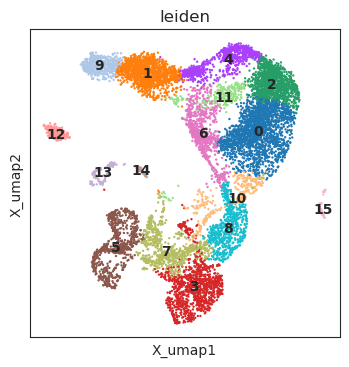

In [11]:
sc.pl.embedding(ad, basis='X_umap', color=['leiden'], legend_loc='on data')

We also need to load in a dictionary of the cell type marker genes for mouse bone marrow mononuclear cells. This marker gene set was generated by public data search, and selected based on RNA expression in single cell data. It can be downloaded [here](https://zenodo.org/records/15054235/files/mouse_bmmc_marker_genes.yaml?download=1), or by running the following cell and entering the desired directory for file download.

In [12]:
# download the marker genes and load in the notebook as a dictionary
data_dir = "../data/"
download_url = "https://zenodo.org/records/15054235/files/mouse_bmmc_marker_genes.yaml?download=1"
file_path = data_dir + "mouse_bmmc_marker_genes.yaml"

with open(file_path, "wb") as f:
    f.write(requests.get("https://zenodo.org/records/15054235/files/mouse_bmmc_marker_genes.yaml?download=1").content)

with open(file_path, "r") as file:
    marker_dict = yaml.safe_load(file)
    
list(marker_dict.keys())

['All Committed B cells',
 'Pro-B cell',
 'Pre-B cell',
 'Pre-B II cell',
 'Immature B cell',
 'Mature Naive B Cell',
 'Memory B Cell',
 'Plasma Cell',
 'General T cell',
 'Treg',
 'CD4 T cell',
 'CD8 T cell',
 'NK',
 'cMoP',
 'Monocyte',
 'cDC',
 'PDC',
 'Non-Classical Monocyte',
 'Basophil',
 'MBEP',
 'Neutrophil',
 'HSC',
 'LMPP',
 'CLP',
 'MKP',
 'Ery P',
 'Mono P',
 'Myelo P']


Below, we will plot the expression of different cell type markers in order to identify which cell clusters belong to which cell type.

# Begin cell typing
## Identifying cluster 12

One way to find out what cell type a cluster belongs to, is to ask what genes are highly enriched in that cluster versus the rest of the cells. Let's look first at cluster 12, which is separating from all of the other cell types.

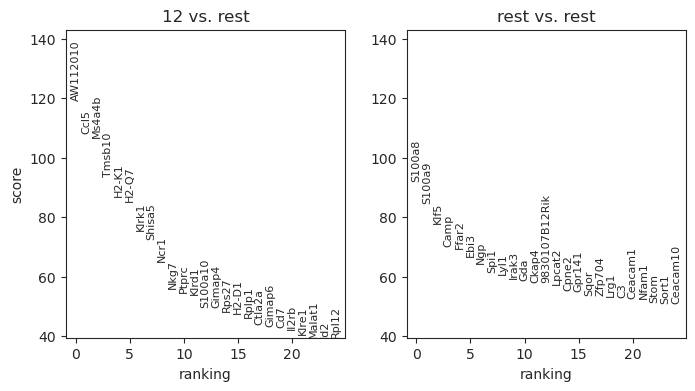

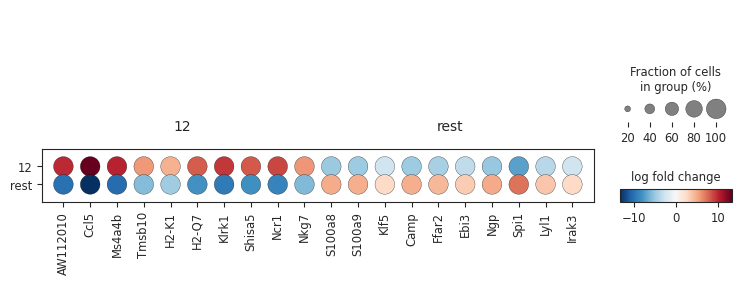

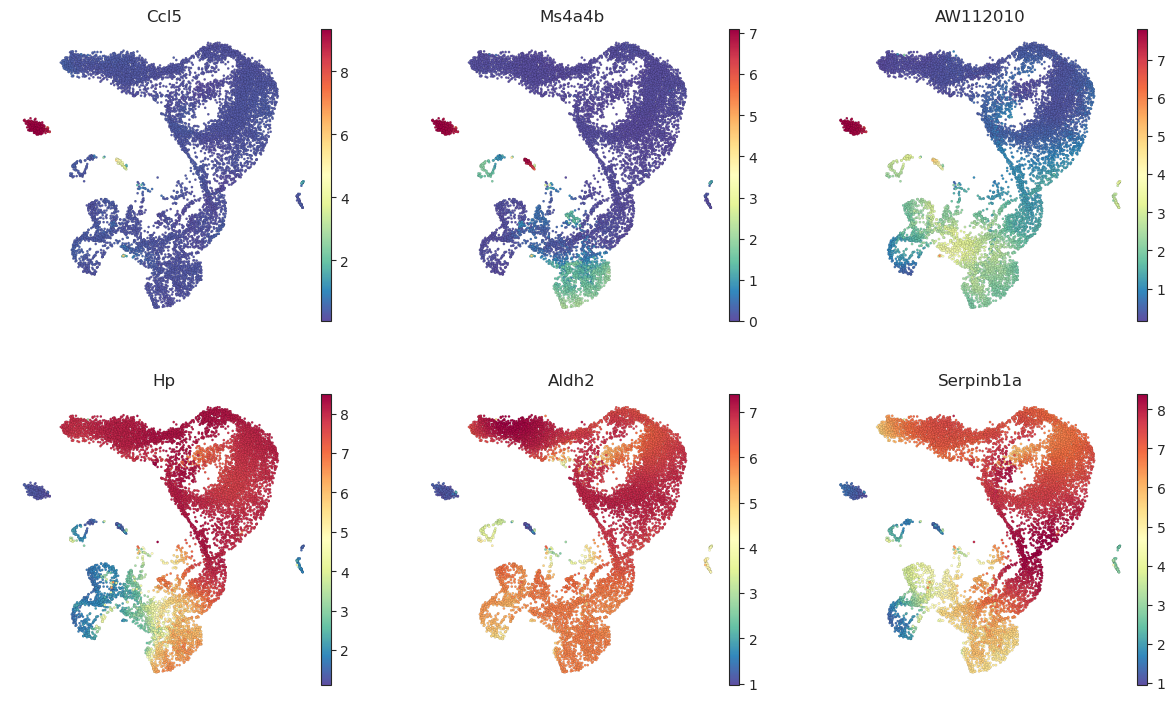

,names,scores,logfoldchanges,pvals,pvals_adj
0,AW112010,119.118477,9.941242,4.846453e-256,1.871236e-253
1,Ccl5,108.171638,13.330020,3.025816e-217,9.193026e-215
2,Ms4a4b,106.987541,10.215981,1.649333e-219,5.180862e-217
3,Tmsb10,93.618324,5.806530,0.000000e+00,0.000000e+00
4,H2-K1,86.988510,4.764865,1.296191e-312,9.608920e-310
...,...,...,...,...,...
18528,Ffar2,-69.521301,-4.402333,7.037667e-274,3.525110e-271
18529,Camp,-70.210266,-4.836217,2.582853e-265,1.196700e-262
18530,Klf5,-77.828545,-2.702216,0.000000e+00,0.000000e+00
18531,S100a9,-84.651596,-4.840198,0.000000e+00,0.000000e+00


In [13]:
subset_and_rank_genes_vs_rest(ad,'12', groupby='leiden')

Based on a quick search, the genes that are highly expressed in cluster 12 appear to be associated with NK/T cells, while cluster 12 does not express genes associated with myeloid lineages.

Now let's figure out whether cluster 12 is NK, or T! To do so, we can use the function plot_markers to look at expression of marker genes for NK cells.

Missing markers for NK:
  - Positive markers not found: Klra
  - Negative markers not found: Cd3e

Plotting POSITIVE markers for: NK


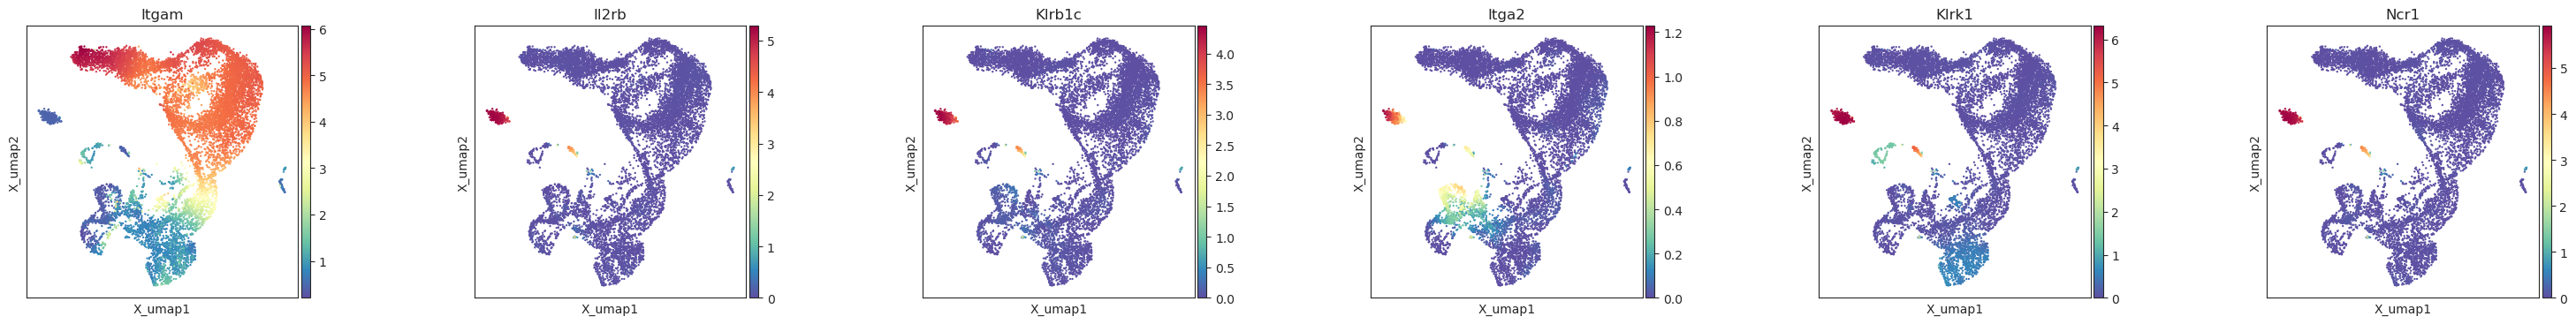


Plotting NEGATIVE markers for: NK (should be LOW expression)


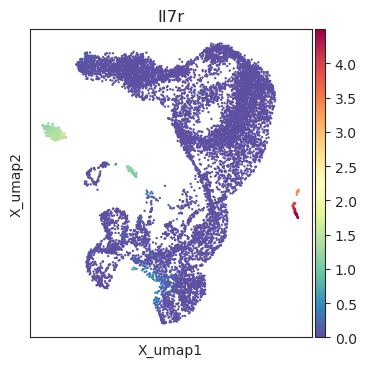


Plotting Dot Plot for POSITIVE markers in NK, grouped by leiden


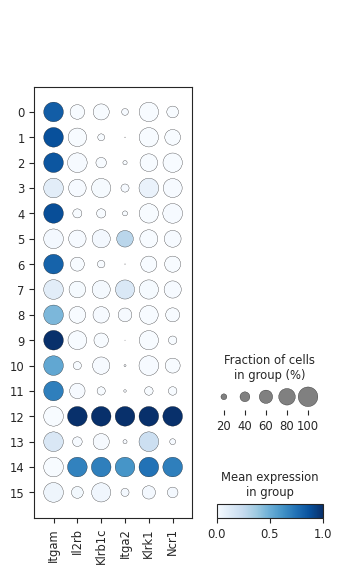

{'NK': {'positive': ['Itgam', 'Il2rb', 'Klrb1c', 'Itga2', 'Klrk1', 'Ncr1'],
  'negative': ['Il7r']}}

In [14]:
plot_markers(ad, marker_dict, cell_type='NK')

It looks like cluster 12 must be NK cells, because they express many NK cell markers, and do not have any CD3. Cd3e is not present in the dataset at all, meaning that there are no T cells here at all.

Now that we know our annotation, we can finally create "annotations", the data frame with cell barcodes and the associated cell type!

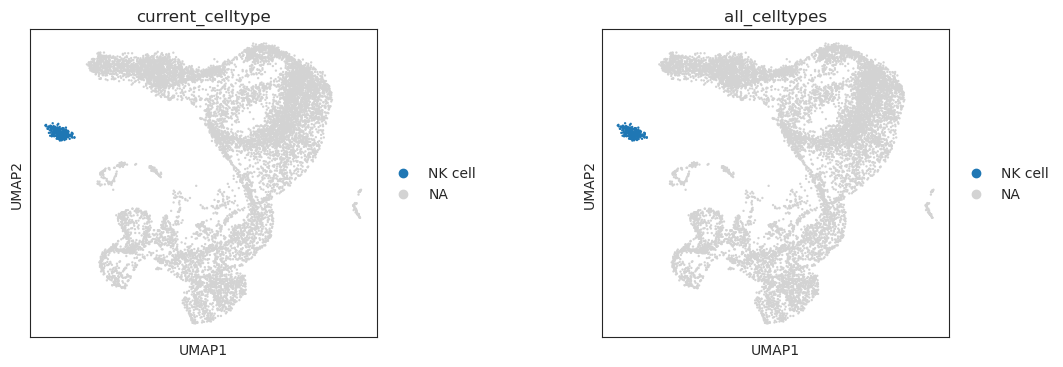

In [15]:
annotations_dict={
    '12' : 'NK cell',
}
annotations = id_celltype(ad, 'leiden', annotations_dict)

In [16]:
# Let's take a look at the first 10 rows of our annotations
annotations[:10]

,cell_barcode,celltype
0,AAATGGAGTACTTGTG-1,NK cell
1,AACCAACCAACTGATC-1,NK cell
2,AACCCAATCATTTACC-1,NK cell
3,AACCCAATCGCACTCT-1,NK cell
4,AACCTTTGTCGATTCA-1,NK cell
5,AACGTCATCGAGCCAC-1,NK cell
6,AACTTCTTCCACCTCA-1,NK cell
7,AACTTCTTCCCTCATG-1,NK cell
8,AAGACAAAGAGTACCG-1,NK cell
9,AAGACTCAGACGGAAA-1,NK cell


Great!

Another way to identify a cell type, is to simply plot expression of the markers directly. Next, we will identify Neutrophils.

## Identifying Neutrophils


Plotting POSITIVE markers for: Neutrophil


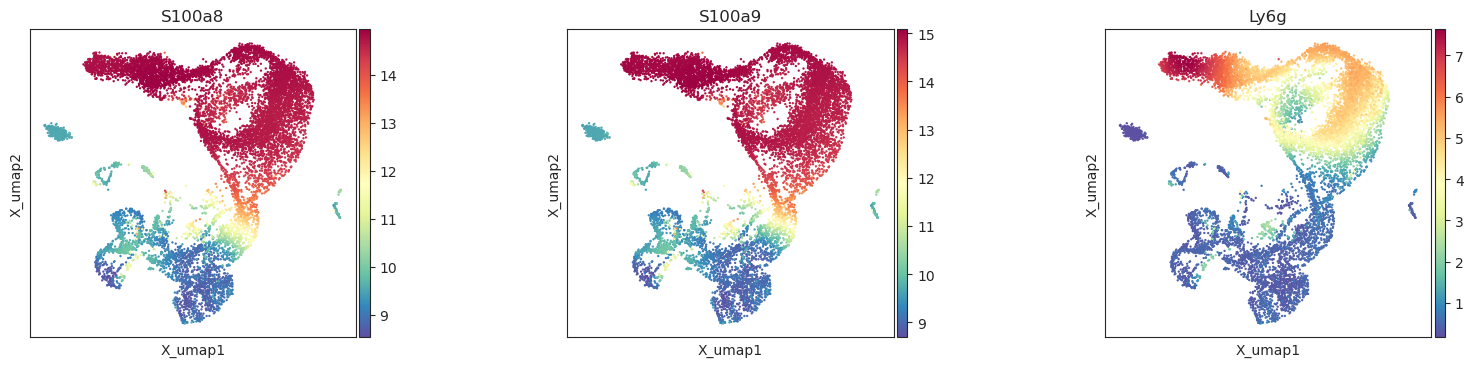


Plotting Dot Plot for POSITIVE markers in Neutrophil, grouped by leiden


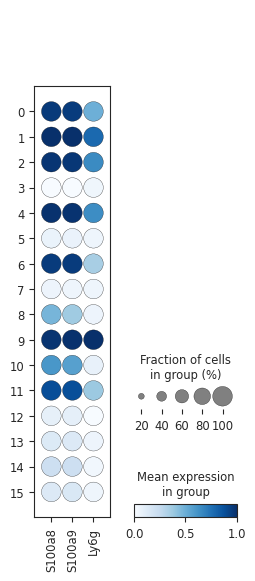

{'Neutrophil': {'positive': ['S100a8', 'S100a9', 'Ly6g'], 'negative': []}}

In [17]:
plot_markers(ad, marker_dict, cell_type='Neutrophil')

It looks like there are many clusters that are all neutrophils. You can specify them all and add them to the existing NK cell annotations by using id_celltype, and including the argument existing_annotations=annotations

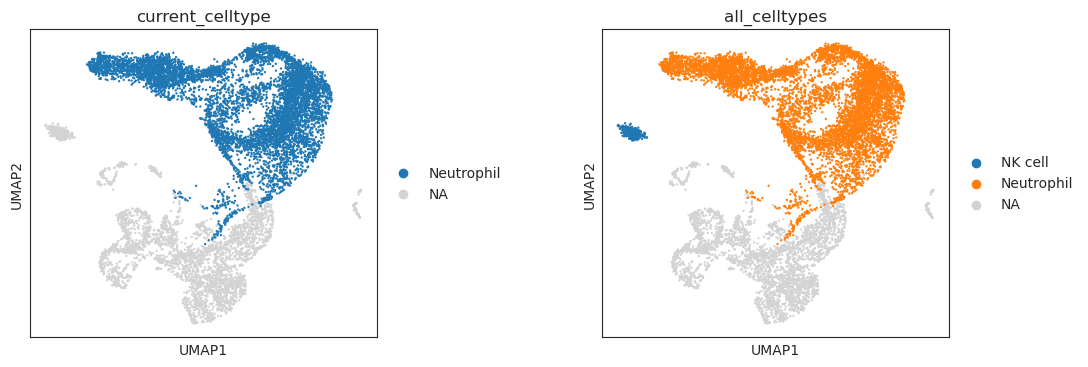

In [18]:
annotations_dict={
    '0' : 'Neutrophil',
    '1' : 'Neutrophil',
    '2' : 'Neutrophil',
    '4' : 'Neutrophil',
    '6' : 'Neutrophil',
    '9' : 'Neutrophil',
    '10' : 'Neutrophil',
    '11' : 'Neutrophil'
}

annotations = id_celltype(ad, 'leiden', annotations_dict, existing_annotations=annotations)

## Discerning between two similar populations
We might also want to distinguish two populations of cells that are nearby to one another, to help discern the cell type identity. For that we can use the function subset_and_rank_genes. Let's take leiden cluster 3 and 8 for example.

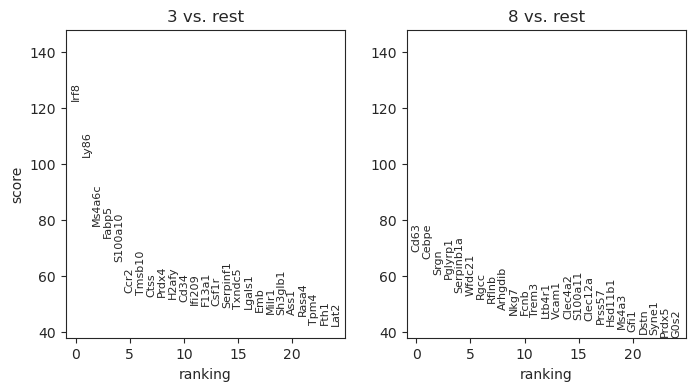

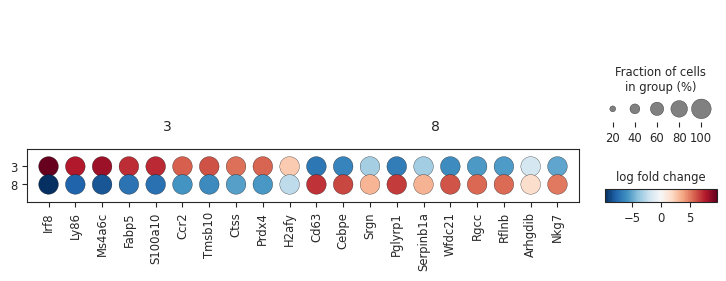

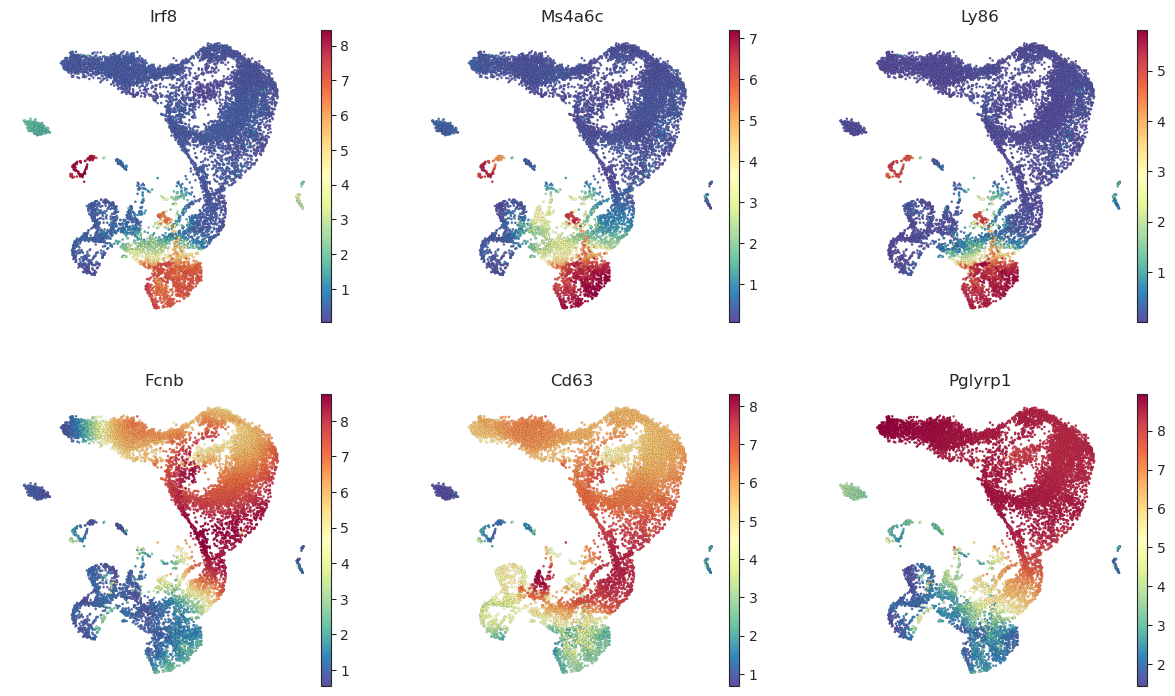

(           names      scores  logfoldchanges  pvals  pvals_adj
 0           Irf8  122.457268        9.667102    0.0        0.0
 1           Ly86  102.763680        7.777317    0.0        0.0
 2         Ms4a6c   77.827995        8.259924    0.0        0.0
 3          Fabp5   73.835876        7.143435    0.0        0.0
 4        S100a10   65.251610        7.224946    0.0        0.0
 ...          ...         ...             ...    ...        ...
 18528  Serpinb1a  -53.883301       -3.325893    0.0        0.0
 18529    Pglyrp1  -58.924099       -6.768132    0.0        0.0
 18530       Srgn  -60.517971       -3.290690    0.0        0.0
 18531      Cebpe  -66.295052       -6.485643    0.0        0.0
 18532       Cd63  -68.638992       -6.950330    0.0        0.0
 
 [18533 rows x 5 columns],
            names      scores  logfoldchanges  pvals  pvals_adj
 0           Cd63   68.638992        6.950330    0.0        0.0
 1          Cebpe   66.295052        6.485643    0.0        0.0
 2         

In [19]:
subset_and_rank_genes(ad,'3', '8', groupby='leiden')

By running a quick search of the genes that popped up, it's clear that leiden cluster 3 is more monocytic, whereas leiden cluster 8 is more granulocytic. Let's check our markers for monocyte progenitors and myeloid progenitors.


Plotting POSITIVE markers for: Mono P


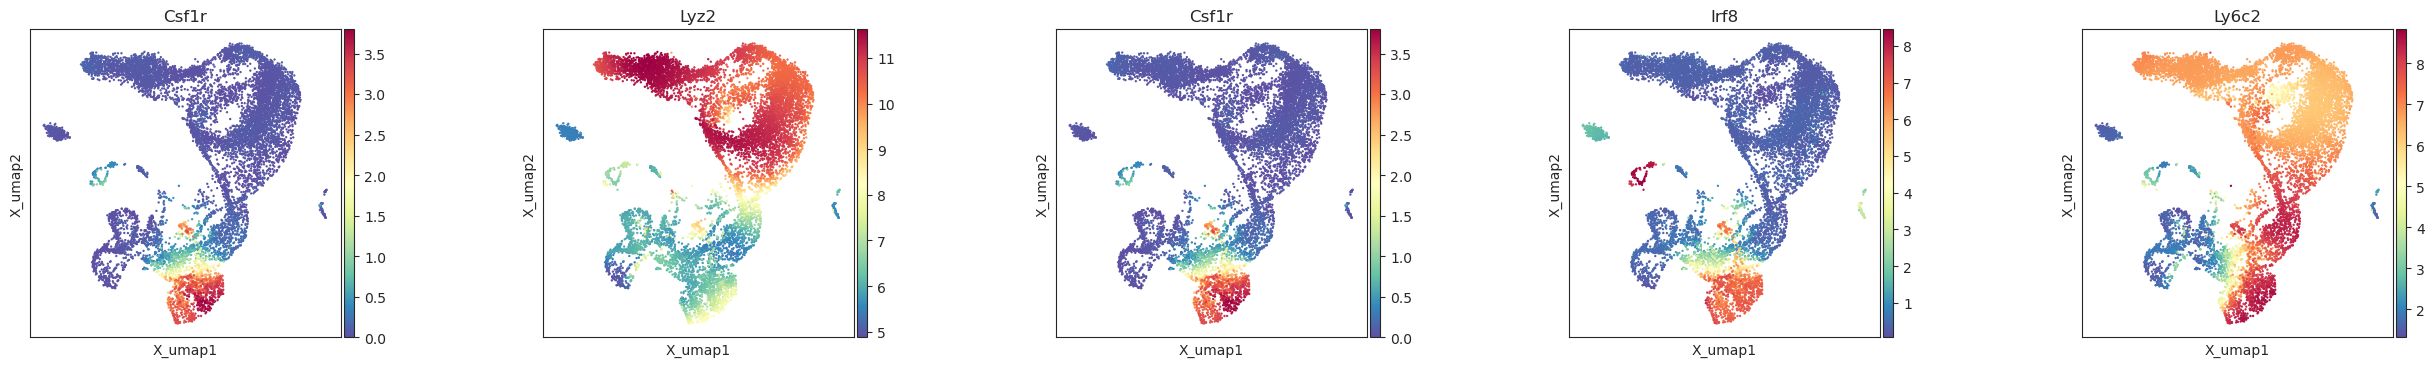


Plotting Dot Plot for POSITIVE markers in Mono P, grouped by leiden


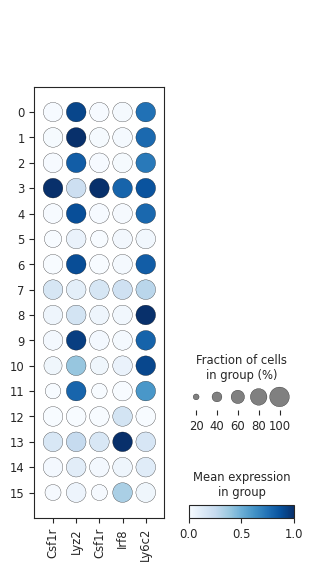

{'Mono P': {'positive': ['Csf1r', 'Lyz2', 'Csf1r', 'Irf8', 'Ly6c2'],
  'negative': []}}

In [20]:
plot_markers(ad, marker_dict, cell_type='Mono P')


Plotting POSITIVE markers for: Myelo P


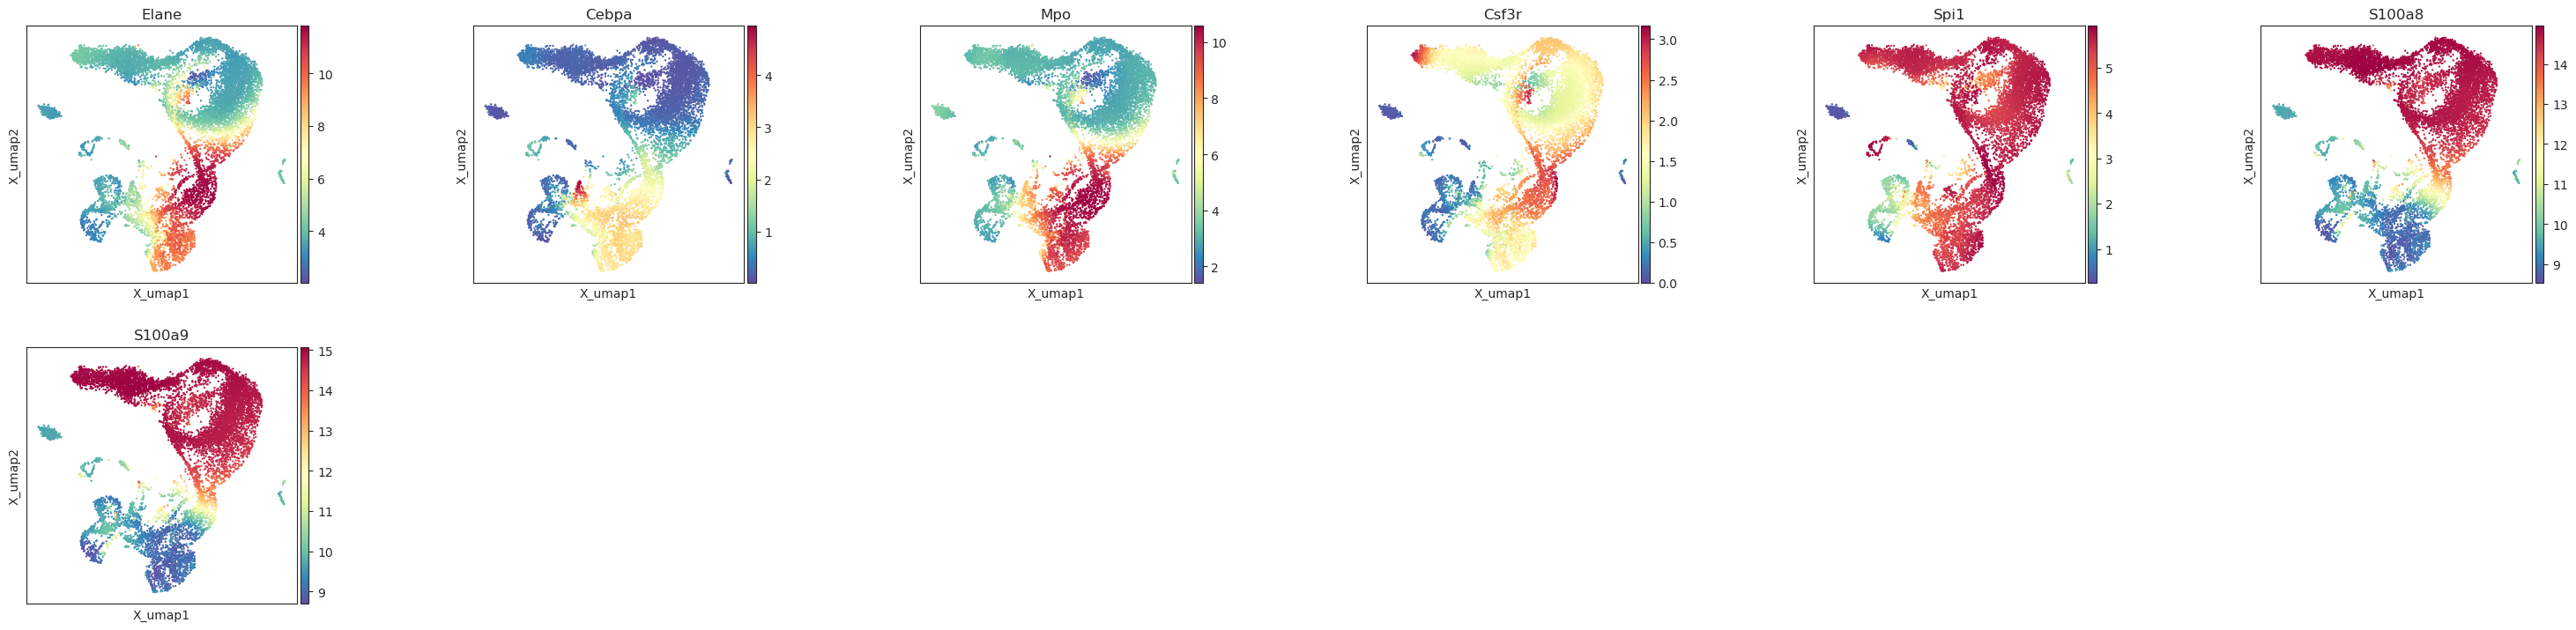


Plotting Dot Plot for POSITIVE markers in Myelo P, grouped by leiden


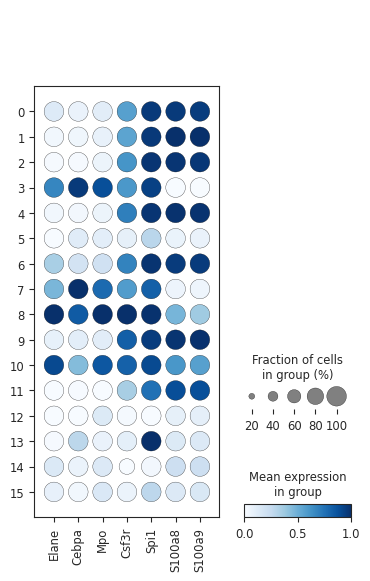

{'Myelo P': {'positive': ['Elane',
   'Cebpa',
   'Mpo',
   'Csf3r',
   'Spi1',
   'S100a8',
   'S100a9'],
  'negative': []}}

In [21]:
plot_markers(ad, marker_dict, cell_type='Myelo P')

Together, the expression profiles for the monocyte progeintor markers and myeloid progenitor markers confirm the hypothesis that cluster 3 is Mono P and cluster 8 is Myelo P. Let's add these annotations too!

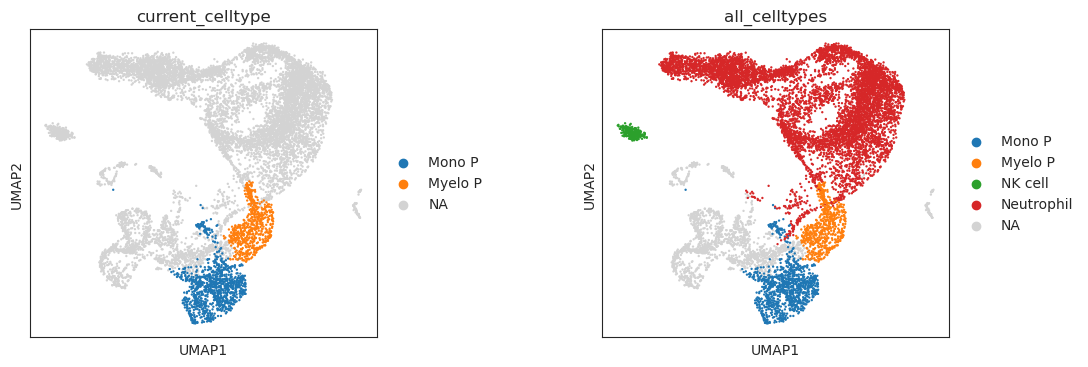

In [22]:
annotations_dict={
    '3' : 'Mono P',
    '8' : 'Myelo P',
}
annotations = id_celltype(ad, 'leiden', annotations_dict, existing_annotations=annotations)

This illustrates a couple of ways that you can go about cell typing using the plotting functions here.


For simiplicity's sake, the remaining clusters will remain un-annotated for now.

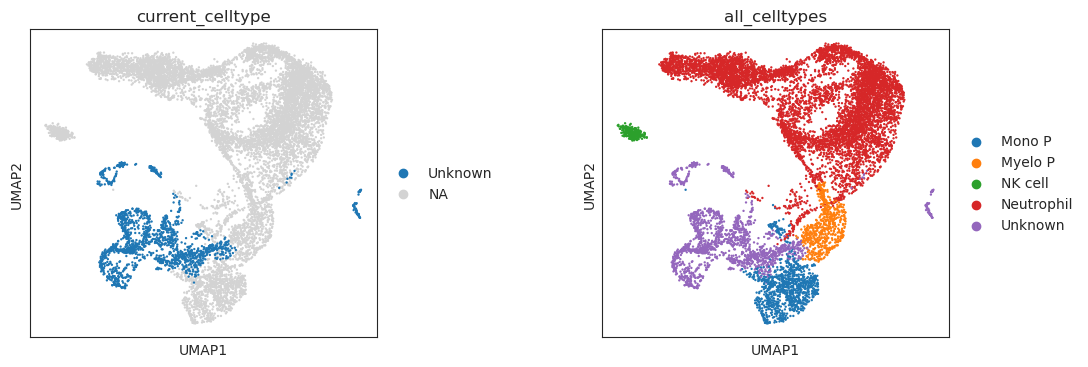

In [23]:
annotations_dict={
    '5' : 'Unknown',
    '7' : 'Unknown',
    '13' : 'Unknown',
    '14' : 'Unknown',
    '15' : 'Unknown',
}
annotations = id_celltype(ad, 'leiden', annotations_dict, existing_annotations=annotations)

# Adding annotations to the anndata

Once we are happy with the annotations, we can add the annotations to the anndata, and do some tidying to get it looking nice.

In [24]:
# Set the cell barcode as the index for annotations
annotations = annotations.set_index("cell_barcode")
annotations

,celltype
cell_barcode,
AAATGGAGTACTTGTG-1,NK cell
AACCAACCAACTGATC-1,NK cell
AACCCAATCATTTACC-1,NK cell
AACCCAATCGCACTCT-1,NK cell
AACCTTTGTCGATTCA-1,NK cell
...,...
TTTGACTAGTCTCCTC-1,Unknown
TTTGATCGTATCAGCT-1,Unknown
TTTGATCGTTAACCTG-1,Unknown


In [25]:
set(annotations['celltype'])

{'Mono P', 'Myelo P', 'NK cell', 'Neutrophil', 'Unknown'}

In [26]:
# Add the annotations to the anndata
ad.obs["celltype"] = ad.obs_names.map(annotations["celltype"].to_dict()).astype("category")

In [27]:
# Take a look at all the cell types that you have annotated
set(ad.obs['celltype'])

{'Mono P', 'Myelo P', 'NK cell', 'Neutrophil', 'Unknown'}

Finally we can add some aesthetic touches to make our annotations look nice. For example, we may want the cells to appear in a certain order on the legend of the UMAP.

In [29]:
# Specify the order you would like the cell types to appear
categories = [
    "Mono P",
    "Myelo P",
    "Neutrophil", 
    "NK cell",
    "Unknown"
]
ad.obs['celltype'].cat.reorder_categories(categories)

AAACCCAAGGTCCGAA-1        Mono P
AAACCCACAATGCAGG-1    Neutrophil
AAACCCACACAGCTTA-1    Neutrophil
AAACCCACACTAGGCC-1    Neutrophil
AAACCCACAGAATCGG-1    Neutrophil
                         ...    
TTTGTTGTCAGGTAAA-1    Neutrophil
TTTGTTGTCCTATTTG-1        Mono P
TTTGTTGTCGAGCTGC-1    Neutrophil
TTTGTTGTCGCGGTAC-1       NK cell
TTTGTTGTCTACGGTA-1    Neutrophil
Name: celltype, Length: 10499, dtype: category
Categories (5, object): ['Mono P', 'Myelo P', 'Neutrophil', 'NK cell', 'Unknown']

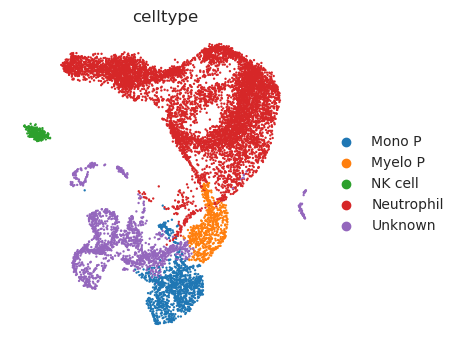

In [30]:
sc.pl.embedding(ad, 
                basis='X_umap', 
                color='celltype',
                frameon=False)

If you aren't happy with the default colors, you can spedcify colors by creating a dictionary mapping and adding it to ad.uns

In [34]:
color_dict = {
    "Mono P": "#EBB27E",
    "Myelo P": "#95BE92",
    "Neutrophil": "#FFC300",
    "NK cell": "#4B0082", 
    "Unknown":"#B0A4BD"
}

In [35]:
# Add the color mapping to ad.uns so you can access it later
ad.uns['celltype_colors'] = color_dict

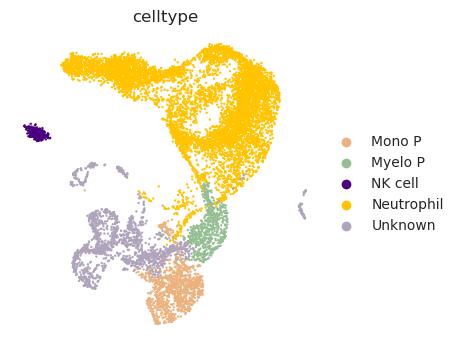

In [36]:
# Plot using your specified colors by using the palette argument
sc.pl.embedding(ad, 
                basis='X_umap', 
                color='celltype',
                frameon=False, 
                palette = ad.uns['celltype_colors'])

That's it. Happy cell typing!